<h1 align="center">1. Análise Exploratória </h1>

In [ ]:
# Instalação de bibliotecas:

!uv pip install pandas
!uv pip install matplotlib

Using Python 3.11.15 environment at: /Users/cintiashinoda/Desktop/public-transit-graph-theory/public-transit-graph-theory-repo/venv
Checked 1 package in 20ms
Using Python 3.11.15 environment at: /Users/cintiashinoda/Desktop/public-transit-graph-theory/public-transit-graph-theory-repo/venv
Checked 1 package in 4ms


In [1]:
# Importação de bibliotecas:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path


# Definição do caminho para os dados:
REPO_ROOT = Path(os.getcwd())
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent

DATA_PATH = REPO_ROOT / 'data' / 'raw' / 'gtfs'

## GTFS - SPTrans

In [ ]:
# Leitura dos arquivos GTFS:

arquivos_gtfs = [
    'agency',
    'calendar',
    'fare_attributes',
    'fare_rules',
    'frequencies',
    'routes',
    'shapes',
    'stop_times',
    'stops',
    'trips'
]


# Dimensões dos 10 arquivos .txt do GTFS:
gtfs = {}
for arquivo in arquivos_gtfs:
    caminho = DATA_PATH / f'{arquivo}.txt'
    gtfs[arquivo] = pd.read_csv(caminho)
    n_linhas, n_colunas = gtfs[arquivo].shape
    print(f" {arquivo:<20} {n_linhas:>10,} linhas | {n_colunas} colunas")

 agency                        1 linhas | 5 colunas
 calendar                      6 linhas | 10 colunas
 fare_attributes               6 linhas | 6 colunas
 fare_rules                5,367 linhas | 5 colunas
 frequencies              40,149 linhas | 4 colunas
 routes                    1,345 linhas | 7 colunas
 shapes                1,133,560 linhas | 5 colunas
 stop_times               98,423 linhas | 5 colunas
 stops                    22,101 linhas | 5 colunas
 trips                     2,254 linhas | 6 colunas


### Modelo Entidade-Relacionamento (MER) do GTFS da SPTrans:

<img align="center" src="../images/GTFS-SPTrans/MER-GTFS-SPTrans.svg" alt="Modelo Entidade-Relacionamento GTFS SPTrans" width="100%"/>

### Modelo Entidade-Relacionamento (MER) Reduzido:

<img align="center" src="../images/GTFS-SPTrans/MER-Reduzido.svg" alt="Modelo Entidade-Relacionamento Reduzido" width="100%"/>

## Arquivos GTFS:

### `agency.txt`

In [ ]:
# Dimensões e tipos de dados do arquivo 'agency.txt`:

print(gtfs['agency'].info())

<class 'pandas.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   agency_id        1 non-null      int64
 1   agency_name      1 non-null      str  
 2   agency_url       1 non-null      str  
 3   agency_timezone  1 non-null      str  
 4   agency_lang      1 non-null      str  
dtypes: int64(1), str(4)
memory usage: 172.0 bytes
None


In [ ]:
# Visualização da única linha do arquivo 'agency.txt`: 

print(gtfs['agency'])

   agency_id agency_name                                agency_url  \
0          1     SPTRANS  http://www.sptrans.com.br/?versao=110226   

     agency_timezone agency_lang  
0  America/Sao_Paulo          pt  


### `calendar.txt`

In [ ]:
# Dimensões e tipos de dados do arquivo 'calendar.txt`:

print(gtfs['calendar'].info())

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   service_id  6 non-null      str  
 1   monday      6 non-null      int64
 2   tuesday     6 non-null      int64
 3   wednesday   6 non-null      int64
 4   thursday    6 non-null      int64
 5   friday      6 non-null      int64
 6   saturday    6 non-null      int64
 7   sunday      6 non-null      int64
 8   start_date  6 non-null      int64
 9   end_date    6 non-null      int64
dtypes: int64(9), str(1)
memory usage: 612.0 bytes
None


In [3]:
# Visualização das 6 linhas do arquivo 'calendar.txt`:

print(gtfs['calendar'])

  service_id  monday  tuesday  wednesday  thursday  friday  saturday  sunday  \
0        USD       1        1          1         1       1         1       1   
1        U__       1        1          1         1       1         0       0   
2        US_       1        1          1         1       1         1       0   
3        _SD       0        0          0         0       0         1       1   
4        __D       0        0          0         0       0         0       1   
5        _S_       0        0          0         0       0         1       0   

   start_date  end_date  
0    20231001  20260901  
1    20231001  20260901  
2    20231001  20260901  
3    20231001  20260901  
4    20231001  20260901  
5    20231001  20260901  


#### Interpretação dos códigos de serviço (`service_id`) presentes no arquivo `calendar.txt`:

- USD: opera todos os dias
- U__: opera somente nos dias úteis
- US_: opera de segunda a sábado
- _SD: opera somente aos sábados e domingos
- __D: opera somente aos domingos
- _S_: opera somente aos sábados

- Período: 10/01/2023 a 09/01/2026

### `routes.txt`

In [ ]:
# Dimensões e tipos de dados do arquivo 'routes.txt`:

print(gtfs['routes'].info())

<class 'pandas.DataFrame'>
RangeIndex: 1345 entries, 0 to 1344
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   route_id          1345 non-null   str  
 1   agency_id         1345 non-null   int64
 2   route_short_name  1345 non-null   str  
 3   route_long_name   1345 non-null   str  
 4   route_type        1345 non-null   int64
 5   route_color       1345 non-null   str  
 6   route_text_color  1336 non-null   str  
dtypes: int64(2), str(5)
memory usage: 73.7 KB
None


In [ ]:
# Visualização das primeiras linhas do arquivo 'routes.txt`:

print(gtfs['routes'].head())

  route_id  agency_id route_short_name  \
0  1012-10          1          1012-10   
1  1012-21          1          1012-21   
2  1014-10          1          1014-10   
3  1015-10          1          1015-10   
4  1016-10          1          1016-10   

                             route_long_name  route_type route_color  \
0        Term. Jd. Britania - Jd. Monte Belo           3      509E2F   
1           Term. Jd. Britânia - Jd. Rosinha           3      509E2F   
2                    Cptm Perus - Morro Doce           3      509E2F   
3  Term. Jd. Britânia - Chác. Maria Trindade           3      509E2F   
4         Cem. Do Horto - Shop. Center Norte           3      002F6C   

  route_text_color  
0           FFFFFF  
1           FFFFFF  
2           FFFFFF  
3           FFFFFF  
4           FFFFFF  


In [ ]:
# Contagem de `route_type` presentes no arquivo 'routes.txt`:

print(gtfs['routes']['route_type'].value_counts())

route_type
3    1332
2       7
1       6
Name: count, dtype: int64


#### Interpretação dos `route_type` presentes no arquivo `routes.txt`:

| route | quantidade | tipo |
|:---:|:---:|:---:|
| 1 | 6 | metrô |
| 2 | 7 | trem |
| 3 | 1332 | ônibus |

### `stops.txt`

In [ ]:
# Dimensões e tipos de dados do arquivo 'stops.txt`:

print(gtfs['stops'].info())

<class 'pandas.DataFrame'>
RangeIndex: 22101 entries, 0 to 22100
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   stop_id    22101 non-null  int64  
 1   stop_name  22101 non-null  str    
 2   stop_desc  20675 non-null  str    
 3   stop_lat   22101 non-null  float64
 4   stop_lon   22101 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 863.4 KB
None


In [ ]:
# Visualização das primeiras linhas do arquivo 'stops.txt`:

print(gtfs['stops'].head())

   stop_id      stop_name stop_desc   stop_lat   stop_lon
0    18848       Clínicas       NaN -23.554022 -46.671108
1    18849  Vila Madalena       NaN -23.546498 -46.691141
2    18850     Consolação       NaN -23.558094 -46.660205
3    18851      Conceição       NaN -23.635039 -46.641239
4    18852      Jabaquara       NaN -23.646033 -46.641028


In [13]:
# valores nulos em `stop_desc`

print(gtfs['stops']['stop_desc'].isnull().sum())

1426


In [ ]:
# latitude e longitude (Limites geográficos da área de estudo):

stops = gtfs['stops']
print(f'Latitude:  {stops.stop_lat.min():.4f} (sul) a {stops.stop_lat.max():.4f} (norte)')
print(f'Longitude: {stops.stop_lon.min():.4f} (oeste) a {stops.stop_lon.max():.4f} (leste)')

Latitude:  -23.9111 (sul) a -23.1956 (norte)
Longitude: -46.9839 (oeste) a -46.1849 (leste)


In [ ]:
# Instalação da biblioteca `geopandas`:
!uv pip install geopandas

Using Python 3.11.15 environment at: /Users/cintiashinoda/Desktop/public-transit-graph-theory/public-transit-graph-theory-repo/venv
Checked 1 package in 3ms


In [4]:
# Importação da biblioteca `geopandas`:
import geopandas as gpd

# Leitura do shapefile dos municípios de São Paulo:
municipios = gpd.read_file(REPO_ROOT / 'data' / 'raw' / 'ibge' / 'SP_Municipios_2024.shp')

# Colunas do shapefile
print("Colunas:", list(municipios.columns))
print()

Colunas: ['CD_MUN', 'NM_MUN', 'CD_RGI', 'NM_RGI', 'CD_RGINT', 'NM_RGINT', 'CD_UF', 'NM_UF', 'SIGLA_UF', 'CD_REGIA', 'NM_REGIA', 'SIGLA_RG', 'CD_CONCU', 'NM_CONCU', 'AREA_KM2', 'geometry']



#### Distribuição Espacial das Paradas e Estações por Modal:


Municípios com ≥5 paradas (receberão label):
  Osasco: 34 paradas
  Itapecerica da Serra: 22 paradas
  Diadema: 17 paradas
  Taboão da Serra: 12 paradas
  Ferraz de Vasconcelos: 5 paradas

Municípios omitidos do label (< 5 paradas):
  Mogi das Cruzes: 4 paradas
  Itapevi: 4 paradas
  Barueri: 4 paradas
  Itaquaquecetuba: 3 paradas
  Mauá: 3 paradas
  Poá: 3 paradas
  Santo André: 3 paradas
  Campo Limpo Paulista: 2 paradas
  Carapicuíba: 2 paradas
  Jandira: 2 paradas
  Embu-Guaçu: 2 paradas
  Franco da Rocha: 2 paradas
  Guarulhos: 2 paradas
  Mairiporã: 1 paradas
  Rio Grande da Serra: 1 paradas
  Jundiaí: 1 paradas
  Francisco Morato: 1 paradas
  Suzano: 1 paradas
  Embu das Artes: 1 paradas
  Caieiras: 1 paradas
  Ribeirão Pires: 1 paradas
  São Caetano do Sul: 1 paradas
  Várzea Paulista: 1 paradas
Municípios com paradas no GTFS: 29
  ['Barueri', 'Caieiras', 'Campo Limpo Paulista', 'Carapicuíba', 'Diadema', 'Embu das Artes', 'Embu-Guaçu', 'Ferraz de Vasconcelos', 'Francisco Morat

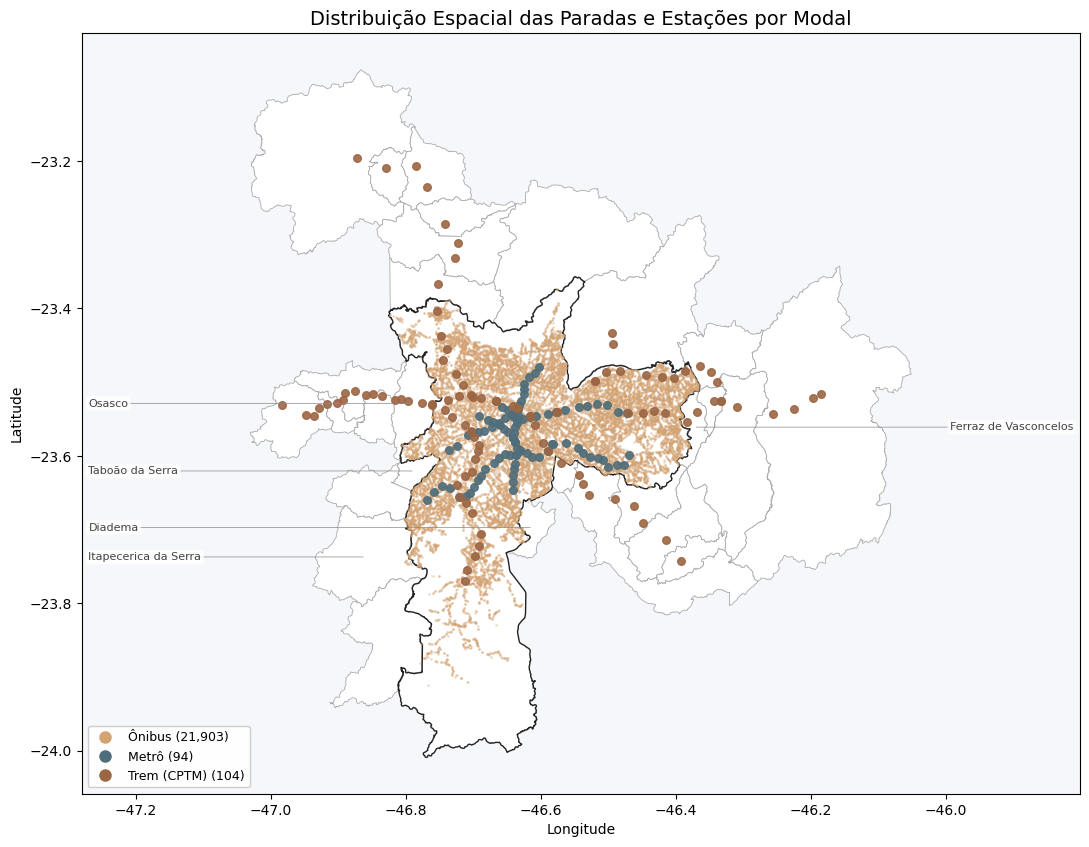

In [ ]:
# Mapa de paradas por modal (SP + municípios adjacentes)

#   1. Spatial join: cada parada é associada ao município que a contém
#   2. Lista os municípios que têm ≥ 5 paradas
#   3. Plota só esses municípios + todas as paradas
# ============================================================

# Carregamentos dos 4 arquivos GTFS:
stops = gtfs['stops']
stop_times = gtfs['stop_times']
trips = gtfs['trips']
routes = gtfs['routes']


# --- DESCOBRIR O MODAL DE CADA PARADA ---
# Caminho: stops → stop_times → trips → routes (route_type)
stop_trip = stop_times[['stop_id', 'trip_id']].drop_duplicates()
stop_route = stop_trip.merge(trips[['trip_id', 'route_id']], on='trip_id')
stop_route = stop_route.merge(routes[['route_id', 'route_type']], on='route_id')
stop_modal = stop_route.groupby('stop_id')['route_type'].first().reset_index()
stops_com_modal = stops.merge(stop_modal, on='stop_id', how='left')


# --- IDENTIFICAR QUAIS MUNICÍPIOS TÊM PARADAS (via spatial join) ---
# 1. Converter as paradas em GeoDataFrame com geometria de pontos
#    EPSG:4326 = sistema de coordenadas WGS84 (lat/lon em graus), padrão do GPS
gdf_stops = gpd.GeoDataFrame(
    stops_com_modal,
    geometry=gpd.points_from_xy(stops_com_modal.stop_lon, stops_com_modal.stop_lat),
    crs='EPSG:4326'
)

# Garantir que ambos os GeoDataFrames usam o mesmo CRS
# (o shapefile do IBGE pode vir em SIRGAS 2000, então reprojetei)
if municipios.crs != gdf_stops.crs:
    municipios = municipios.to_crs(gdf_stops.crs)

# 2. Spatial join: para cada parada, descobrir em qual município ela cai
#    predicate='within' = parada está DENTRO do polígono do município
stops_com_municipio = gpd.sjoin(
    gdf_stops, municipios[['NM_MUN', 'geometry']],
    how='left', predicate='within'
)

# 3. Lista dos municípios que efetivamente têm paradas
municipios_com_paradas = stops_com_municipio['NM_MUN'].dropna().unique()


# Contar paradas por município (para decidir quais terão label)
paradas_por_municipio = (
    stops_com_municipio['NM_MUN']
    .value_counts()
    .to_dict()
)

# Limiar mínimo para receber label nominal (5)
MIN_PARADAS_PARA_LABEL = 5

municipios_com_label = {
    m for m, n in paradas_por_municipio.items()
    if n >= MIN_PARADAS_PARA_LABEL and m != 'São Paulo'
}

print(f"\nMunicípios com ≥{MIN_PARADAS_PARA_LABEL} paradas (receberão label):")
for m in sorted(municipios_com_label, key=lambda x: -paradas_por_municipio[x]):
    print(f"  {m}: {paradas_por_municipio[m]} paradas")

municipios_sem_label = {
    m for m in municipios_com_paradas
    if m not in municipios_com_label and m != 'São Paulo'
}
if municipios_sem_label:
    print(f"\nMunicípios omitidos do label (< {MIN_PARADAS_PARA_LABEL} paradas):")
    for m in sorted(municipios_sem_label, key=lambda x: -paradas_por_municipio.get(x, 0)):
        print(f"  {m}: {paradas_por_municipio.get(m, 0)} paradas")

print(f"Municípios com paradas no GTFS: {len(municipios_com_paradas)}")
print(f"  {sorted(municipios_com_paradas)}")

# 4. Filtrar o shapefile para mostrar só esses municípios
mask_relevantes = municipios['NM_MUN'].isin(municipios_com_paradas)
sp_cidade = municipios[municipios['NM_MUN'] == 'São Paulo']
adjacentes = municipios[mask_relevantes & (municipios['NM_MUN'] != 'São Paulo')]

# Bounds = união de todos os municípios relevantes
bounds = municipios[mask_relevantes].total_bounds  # [lon_min, lat_min, lon_max, lat_max]
margem = 0.02

# --- PLOTAR ---
fig, ax = plt.subplots(figsize=(11, 11))
ax.set_facecolor('#f5f7fa')

# Camada 1: municípios adjacentes (preenchimento bem claro, borda cinza)
adjacentes.plot(
    ax=ax,
    facecolor='#ffffff',
    edgecolor='#aaaaaa',
    linewidth=0.6,
    zorder=1
)

# Camada 2: município de São Paulo destacado (preenchimento neutro, borda escura)
sp_cidade.plot(
    ax=ax,
    facecolor='#ffffff',
    edgecolor='#222222',
    linewidth=1,
    zorder=2
)

# Camada 3: paradas por modal (ônibus por baixo, metrô/CPTM por cima)
cores = {3: '#D4A373', 1: '#4F6D7A', 2: '#9C6644'}
nomes = {3: 'Ônibus', 1: 'Metrô', 2: 'Trem (CPTM)'}

for route_type in [3, 1, 2]:
    mask = stops_com_modal['route_type'] == route_type
    qtd = mask.sum()
    ax.scatter(
        stops_com_modal.loc[mask, 'stop_lon'],
        stops_com_modal.loc[mask, 'stop_lat'],
        s=1 if route_type == 3 else 30,
        alpha=0.3 if route_type == 3 else 0.9,
        color=cores[route_type],
        label=f"{nomes[route_type]} ({qtd:,})",
        zorder=3 if route_type == 3 else 4
    )

# Limitar o mapa à extensão dos municípios relevantes
# Margens DESIGUAIS: mais espaço nas laterais (esquerda/direita) para os labels
margem_horizontal = 0.25
margem_vertical = 0.05
ax.set_xlim(bounds[0] - margem_horizontal, bounds[2] + margem_horizontal)
ax.set_ylim(bounds[1] - margem_vertical, bounds[3] + margem_vertical)

# --- CALLOUTS DOS MUNICÍPIOS ADJACENTES ---
# Estratégia melhorada:
#   1. Cada label fica posicionado na latitude real do seu centróide
#   2. Resolução iterativa de colisões: se dois labels do mesmo lado estão muito próximos verticalmente, empurra o de baixo pra baixo
#   3. Reserva espaço inferior para a legenda

import numpy as np

# Calcular centróides — APENAS dos municípios que receberão label
adjacentes_info = []
for _, row in adjacentes.iterrows():
    if row['NM_MUN'] not in municipios_com_label:
        continue  # município mostrado no mapa, mas sem callout
    centroid = row.geometry.centroid
    adjacentes_info.append({
        'nome': row['NM_MUN'],
        'cx': centroid.x,
        'cy': centroid.y,
    })

# Centro horizontal do mapa (para decidir esquerda vs direita)
centro_x = (bounds[0] + bounds[2]) / 2

# Separar municípios em duas colunas pela posição relativa a SP
left_side = [m for m in adjacentes_info if m['cx'] < centro_x]
right_side = [m for m in adjacentes_info if m['cx'] >= centro_x]

# Posições X dos labels (fora dos polígonos, dentro da margem extra)
x_label_left = bounds[0] - margem_horizontal + 0.01
x_label_right = bounds[2] + margem_horizontal - 0.01

# Zona reservada para a legenda (canto inferior esquerdo)
# Estimativa empírica: legenda ocupa ~12% da altura na base
legenda_y_top = bounds[1] + 0.12 * (bounds[3] - bounds[1])

def resolver_colisoes(municipios_lista, y_min, y_max, evitar_zona_legenda=False):
    """
    Posiciona labels começando na latitude real do centróide e
    empurra para resolver sobreposições.

    municipios_lista: lista de dicts com 'nome', 'cx', 'cy'
    y_min, y_max: limites verticais do mapa
    evitar_zona_legenda: se True, empurra labels que cairiam sobre a legenda
    """
    if not municipios_lista:
        return []

    # Espaço vertical mínimo entre labels (em graus)
    # Em São Paulo, ~0.025 graus ≈ 2.7km — suficiente pra fonte 8pt
    min_spacing = 0.030

    # Ordena por latitude do centróide (norte → sul)
    sorted_munis = sorted(municipios_lista, key=lambda m: -m['cy'])

    # Posição inicial: latitude real do centróide
    posicoes = [m['cy'] for m in sorted_munis]

    # Limita ao range visível
    posicoes = [max(y_min, min(y_max, p)) for p in posicoes]

    # Resolve colisões: percorre de cima para baixo, empurra para baixo
    for i in range(1, len(posicoes)):
        if posicoes[i - 1] - posicoes[i] < min_spacing:
            posicoes[i] = posicoes[i - 1] - min_spacing

    # Se algum label foi empurrado abaixo do limite inferior, ajusta de baixo pra cima
    if posicoes and posicoes[-1] < y_min:
        posicoes[-1] = y_min
        for i in range(len(posicoes) - 2, -1, -1):
            if posicoes[i + 1] - posicoes[i] > -min_spacing:
                posicoes[i] = posicoes[i + 1] + min_spacing

    # Se está no lado da legenda, empurra labels que caíram na zona de legenda
    if evitar_zona_legenda:
        for i in range(len(posicoes) - 1, -1, -1):
            if posicoes[i] < legenda_y_top:
                # Empurra esse label e os anteriores para cima até sair da zona
                deslocamento = legenda_y_top - posicoes[i]
                for j in range(i + 1):
                    posicoes[j] += deslocamento
                # Re-resolve colisões em cascata pra cima
                for j in range(i, 0, -1):
                    if posicoes[j - 1] - posicoes[j] < min_spacing:
                        posicoes[j - 1] = posicoes[j] + min_spacing
                break

    return [(m, p) for m, p in zip(sorted_munis, posicoes)]

y_min_lbl = bounds[1] + 0.01
y_max_lbl = bounds[3] - 0.01

left_posicionados = resolver_colisoes(
    left_side, y_min_lbl, y_max_lbl, evitar_zona_legenda=True
)
right_posicionados = resolver_colisoes(
    right_side, y_min_lbl, y_max_lbl, evitar_zona_legenda=False
)

def plotar_callout(ax, nome, cx, cy, lx, ly, ha):
    ax.annotate(
        '',
        xy=(cx, cy),
        xytext=(lx, ly),
        arrowprops=dict(
            arrowstyle='-',
            color='#888888',
            linewidth=0.5,
            shrinkA=0,
            shrinkB=2,
        ),
        zorder=5,
    )
    ax.text(
        lx, ly, nome,
        fontsize=8,
        color='#444444',
        ha=ha,
        va='center',
        zorder=6,
        bbox=dict(
            boxstyle='round,pad=0.2',
            facecolor='white',
            edgecolor='none',
            alpha=0.85,
        ),
    )

for m, ly in left_posicionados:
    plotar_callout(ax, m['nome'], m['cx'], m['cy'], x_label_left, ly, ha='left')

for m, ly in right_posicionados:
    plotar_callout(ax, m['nome'], m['cx'], m['cy'], x_label_right, ly, ha='right')

# --- TÍTULO, EIXOS E LEGENDA ---
ax.set_title(
    'Distribuição Espacial das Paradas e Estações por Modal',
    fontsize=14,
    fontweight='regular'
)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
# --- LEGENDA COM MARCADORES UNIFORMES ---
# Os pontos no mapa têm tamanhos diferentes por modal (ônibus=1, metrô/cptm=30),
# mas na legenda têm tamanhos iguais
from matplotlib.lines import Line2D

handles_legenda = [
    Line2D(
        [0], [0],
        marker='o',
        color='none',
        markerfacecolor=cores[rt],
        markeredgecolor=cores[rt],
        markersize=8,
        label=f"{nomes[rt]} ({(stops_com_modal['route_type'] == rt).sum():,})",
    )
    for rt in [3, 1, 2]
]

ax.legend(
    handles=handles_legenda,
    loc='lower left',
    fontsize=9,
    framealpha=0.95,
)

plt.tight_layout()
plt.savefig(
    str(REPO_ROOT / 'outputs' / 'mapa_paradas_modal_sp_rmsp.png'),
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [ ]:
# Diagnóstico do spatial join

print(f"Total de paradas (gdf_stops):      {len(gdf_stops):,}")
print(f"Total após sjoin:                  {len(stops_com_municipio):,}")
print(f"Paradas com NM_MUN nulo:           {stops_com_municipio['NM_MUN'].isna().sum():,}")
print(f"\nTop 20 municípios por nº de paradas:")
print(
    stops_com_municipio['NM_MUN']
    .value_counts(dropna=False)
    .head(20)
    .to_string()
)
print(f"\nTotal de municípios distintos: {stops_com_municipio['NM_MUN'].nunique()}")

Total de paradas (gdf_stops):      22,101
Total após sjoin:                  22,101
Paradas com NM_MUN nulo:           0

Top 20 municípios por nº de paradas:
NM_MUN
São Paulo                21965
Osasco                      34
Itapecerica da Serra        22
Diadema                     17
Taboão da Serra             12
Ferraz de Vasconcelos        5
Itapevi                      4
Barueri                      4
Mogi das Cruzes              4
Poá                          3
Itaquaquecetuba              3
Santo André                  3
Mauá                         3
Franco da Rocha              2
Jandira                      2
Carapicuíba                  2
Campo Limpo Paulista         2
Guarulhos                    2
Embu-Guaçu                   2
Suzano                       1

Total de municípios distintos: 29


### `trips.txt`

In [ ]:
# Dimensões e tipos de dados do arquivo 'trips.txt`:

print(gtfs['trips'].info())

<class 'pandas.DataFrame'>
RangeIndex: 2254 entries, 0 to 2253
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   route_id       2254 non-null   str  
 1   service_id     2254 non-null   str  
 2   trip_id        2254 non-null   str  
 3   trip_headsign  2254 non-null   str  
 4   direction_id   2254 non-null   int64
 5   shape_id       2254 non-null   int64
dtypes: int64(2), str(4)
memory usage: 105.8 KB
None


In [20]:
trips = gtfs['trips']

print(f'Total de viagens: {len(trips):,}')
print(f'\nPor tipo de serviço:')
for sid, count in trips['service_id'].value_counts().items():
    print(f"- {sid}: {count:,} viagens")

print(f"\nPor direção:")
print(f"- Ida (0):   {(trips['direction_id'] == 0).sum():,}")
print(f"- Volta (1): {(trips['direction_id'] == 1).sum():,}")

Total de viagens: 2,254

Por tipo de serviço:
- USD: 1,801 viagens
- U__: 260 viagens
- US_: 193 viagens

Por direção:
- Ida (0):   1,306
- Volta (1): 948


In [21]:
print((trips["direction_id"] == 0).sum() - (trips["direction_id"] == 1).sum())

358


358 viagens não têm volta definida: linhas circulares ou dados incompletos

### `stop_times.txt`

In [ ]:
# Dimensões e tipos de dados do arquivo 'stop_times.txt`:

print(gtfs['stop_times'].info())

<class 'pandas.DataFrame'>
RangeIndex: 98423 entries, 0 to 98422
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   trip_id         98423 non-null  str  
 1   arrival_time    98423 non-null  str  
 2   departure_time  98423 non-null  str  
 3   stop_id         98423 non-null  int64
 4   stop_sequence   98423 non-null  int64
dtypes: int64(2), str(3)
memory usage: 3.8 MB
None


In [23]:
print(f"Total de registros: {len(stop_times):,}")

# Quantas paradas cada viagem percorre?
# agrupa por trip_id

paradas_por_viagem = stop_times.groupby('trip_id').size()

print(f"\nParadas por viagem:")
print(f"Média:   {paradas_por_viagem.mean():.1f}")
print(f"Mediana: {paradas_por_viagem.median():.0f}")
print(f"Mínimo:  {paradas_por_viagem.min()}")
print(f"Máximo:  {paradas_por_viagem.max()}")


# Exemplo: ver as paradas de uma viagem específica
exemplo_trip = stop_times[stop_times['trip_id'] == trips.iloc[0]['trip_id']]
exemplo_trip = exemplo_trip.sort_values('stop_sequence')
exemplo_trip = exemplo_trip.merge(gtfs['stops'][['stop_id', 'stop_name']], on='stop_id')

print(f"\nExemplo — viagem {trips.iloc[0]['trip_id']}:")
print(f"Rota: {trips.iloc[0]['route_id']} | Destino: {trips.iloc[0]['trip_headsign']}")
print(exemplo_trip[['stop_sequence', 'arrival_time', 'stop_name']].head(10).to_string(index=False))
print(f"({len(exemplo_trip)} paradas no total)")

Total de registros: 98,423

Paradas por viagem:
Média:   43.7
Mediana: 42
Mínimo:  1
Máximo:  146

Exemplo — viagem 1012-10-0:
Rota: 1012-10 | Destino: Jd. Monte Belo
 stop_sequence arrival_time                         stop_name
             1     07:00:00          Terminal Jardim Britânia
             2     07:01:18 R. Delsuc Alves De Magalhães, 194
             3     07:02:36 R. Delsuc Alves De Magalhães, 538
             4     07:03:54    Estr. Cel. José Gladiador, 262
             5     07:05:12      R. Virgínia Castiglioni, 381
             6     07:06:30                   R. Nestor Gomes
             7     07:07:48           R. Alberto Alvarez, 135
             8     07:09:06          R. Dionísio Bellante, 29
             9     07:10:24      R. João Fernandes Vieira, 92
            10     07:11:42            Estr. De Pirapora, 850
(42 paradas no total)


- Os horários são espaçados em ~1min20s — isso é o tempo estimado entre paradas. 
- A viagem 1012-10-0 sai do Terminal Jardim Britânia e faz 41 paradas até o Jd. Monte Belo.
- Mínimo de 1 parada pode ser um dado incorreto
- 146 paradas numa única viagem é uma linha bem longa.

### `frequencies.txt`

In [ ]:
# Dimensões e tipos de dados do arquivo 'frequencies.txt`:

print(gtfs['frequencies'].info())

<class 'pandas.DataFrame'>
RangeIndex: 40149 entries, 0 to 40148
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   trip_id       40149 non-null  str  
 1   start_time    40149 non-null  str  
 2   end_time      40149 non-null  str  
 3   headway_secs  40149 non-null  int64
dtypes: int64(1), str(3)
memory usage: 1.2 MB
None


In [ ]:
# Análise do arquivo 'frequencies.txt`:

frequencies = gtfs['frequencies']

print(f"Total de registros: {len(frequencies):,}")
print(f"Trips com frequência definida: {frequencies['trip_id'].nunique():,}")

# Converter headway de segundos para minutos:
frequencies['headway_min'] = frequencies['headway_secs'] / 60

print("\nHeadway (intervalo entre veículos):")
print(f"Mínimo:  {frequencies['headway_min'].min():.1f} min")
print(f"Média:   {frequencies['headway_min'].mean():.1f} min")
print(f"Mediana: {frequencies['headway_min'].median():.1f} min")
print(f"Máximo:  {frequencies['headway_min'].max():.1f} min")

# Extrair a hora de início pra analisar headway ao longo do dia
# start_time é string "HH:MM:SS", extrair só as horas com str.split
frequencies['hora'] = frequencies['start_time'].str.split(':').str[0].astype(int)

# Calcular headway médio por hora do dia
# os horários de pico o serviço é mais frequente?
headway_por_hora = frequencies.groupby('hora')['headway_min'].mean()


print("\nHeadway médio por faixa horária:")
for hora, headway in headway_por_hora.items():
    # Criar barra visual proporcional ao headway
    barra = '█' * int(headway / 2)
    print(f"{hora:02d}h: {headway:5.1f} min  {barra}")

Total de registros: 40,149
Trips com frequência definida: 2,254

Headway (intervalo entre veículos):
Mínimo:  1.0 min
Média:   21.4 min
Mediana: 20.0 min
Máximo:  60.0 min

Headway médio por faixa horária:
00h:  42.5 min  █████████████████████
01h:  52.9 min  ██████████████████████████
02h:  47.2 min  ███████████████████████
03h:  49.8 min  ████████████████████████
04h:  33.5 min  ████████████████
05h:  19.0 min  █████████
06h:  15.2 min  ███████
07h:  16.0 min  ████████
08h:  17.5 min  ████████
09h:  19.6 min  █████████
10h:  20.4 min  ██████████
11h:  20.2 min  ██████████
12h:  19.3 min  █████████
13h:  18.5 min  █████████
14h:  17.8 min  ████████
15h:  17.3 min  ████████
16h:  16.5 min  ████████
17h:  16.9 min  ████████
18h:  18.3 min  █████████
19h:  20.3 min  ██████████
20h:  21.5 min  ██████████
21h:  22.2 min  ███████████
22h:  23.4 min  ███████████
23h:  29.4 min  ██████████████


- Madrugada (0h-4h): *headway*entre 34 e 53 minutos
- Pico da manhã (5h-7h): *headway* entre 15 e 19 minutos (aumento da oferta)
- Entrepico (8h-14h): *headway* entre 18 e 20 minutos (estável)
- Pico da tarde (15h-18h): *headway* estável entre 17 e 18 minutos
- Noite (19h-23): *headway* aumento gradual de 20 a 29 minutos

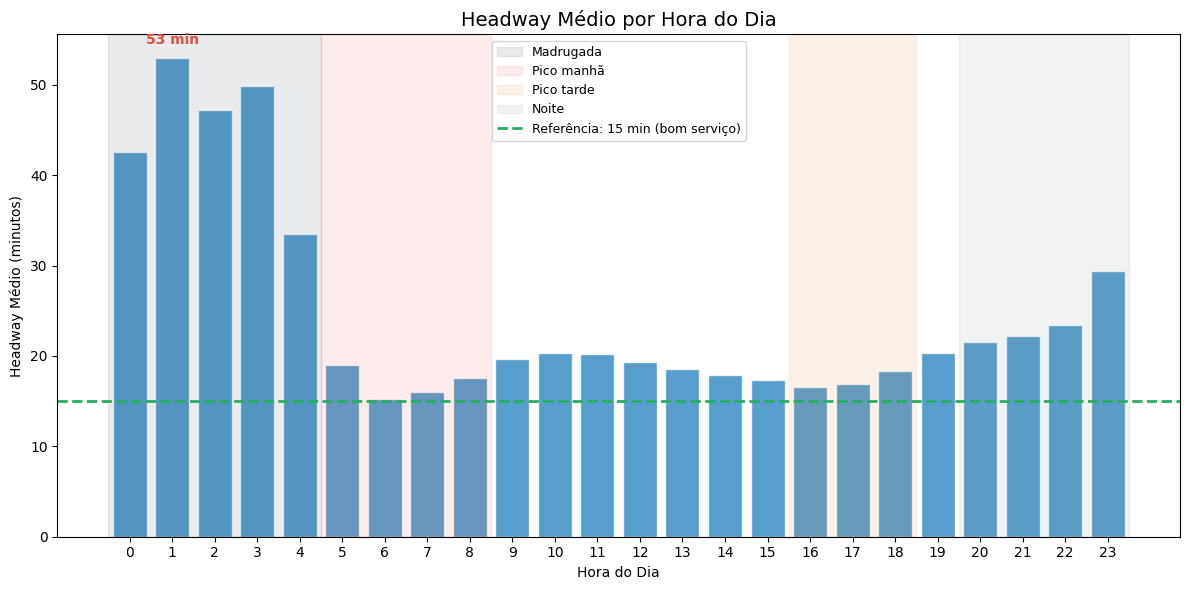

Salvo em: outputs/headway_por_hora.png


In [26]:
fig, ax = plt.subplots(figsize=(12, 6))

# Plotar barras de headway por hora
ax.bar(
    headway_por_hora.index,       # eixo X = hora do dia
    headway_por_hora.values,      # eixo Y = headway médio em minutos
    color='#2e86c1',
    alpha=0.8,
    edgecolor='white'
)

# faixas coloridas pra contexto
# axvspan(x_inicio, x_fim) pinta uma faixa vertical
ax.axvspan(-0.5, 4.5, alpha=0.1, color='#2c3e50', label='Madrugada')   # 0h-4h
ax.axvspan(4.5, 8.5, alpha=0.1, color='#e74c3c', label='Pico manhã')   # 5h-8h
ax.axvspan(15.5, 18.5, alpha=0.1, color='#e67e22', label='Pico tarde') # pico tarde
ax.axvspan(19.5, 23.5, alpha=0.1, color='#7f8c8d', label='Noite')      # noite

# Linha de referência: 15 min = bom headway
ax.axhline(
    y=15, color='#27ae60', linestyle='--', linewidth=2,
    label='Referência: 15 min (bom serviço)'
)


ax.annotate(
    f'{headway_por_hora.max():.0f} min',
    xy=(headway_por_hora.idxmax(), headway_por_hora.max()),
    xytext=(0, 10),
    textcoords='offset points',
    ha='center', fontweight='bold', color='#e74c3c'
)

ax.set_title('Headway Médio por Hora do Dia', fontsize=14)
ax.set_xlabel('Hora do Dia')
ax.set_ylabel('Headway Médio (minutos)')
ax.set_xticks(range(0, 24))
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(str(REPO_ROOT / 'outputs' / 'headway_por_hora.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Salvo em: outputs/headway_por_hora.png")

### `fare_attributes.txt`

In [ ]:
# Dimensões e tipos de dados do arquivo 'fare_attributes.txt`:

print(gtfs['fare_attributes'].info())

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fare_id            6 non-null      str    
 1   price              6 non-null      float64
 2   currency_type      6 non-null      str    
 3   payment_method     6 non-null      int64  
 4   transfers          0 non-null      float64
 5   transfer_duration  6 non-null      int64  
dtypes: float64(2), int64(2), str(2)
memory usage: 420.0 bytes
None


### `fare_rules.txt`

In [ ]:
# Dimensões e tipos de dados do arquivo 'fare_rules.txt`:

print(gtfs['fare_rules'].info())

<class 'pandas.DataFrame'>
RangeIndex: 5367 entries, 0 to 5366
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   fare_id         5367 non-null   str    
 1   route_id        5367 non-null   str    
 2   origin_id       0 non-null      float64
 3   destination_id  0 non-null      float64
 4   contains_id     0 non-null      float64
dtypes: float64(3), str(2)
memory usage: 209.8 KB
None


### `shapes.txt`

In [ ]:
# Dimensões e tipos de dados do arquivo 'shapes.txt`:

print(gtfs['shapes'].info())

<class 'pandas.DataFrame'>
RangeIndex: 1133560 entries, 0 to 1133559
Data columns (total 5 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   shape_id             1133560 non-null  int64  
 1   shape_pt_lat         1133560 non-null  float64
 2   shape_pt_lon         1133560 non-null  float64
 3   shape_pt_sequence    1133560 non-null  int64  
 4   shape_dist_traveled  1133560 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 43.2 MB
None
